In [42]:
import torch 
from torch_geometric.data import Data
import pandas as pd
import numpy as np
from torch_geometric.utils import to_networkx
import matplotlib.pyplot as plt

def graph_encode(data, edge_cols: list, 
                 linegraph: bool, 
                target_col: str = None
                ):
    """ Convert flow dataframe  (all cols numerical) 
    to flow graph """

    # ----- build edge features -----
    attrs = [
        c for c in data.columns if c not in 
        edge_cols + ([target_col] if target_col else [])
    ]

    x = data[attrs].to_numpy(dtype=np.float32)
    edge_attr = torch.tensor(x, dtype=torch.float)

    nodes = pd.concat([data['src'], data['dst']]).unique()
    node_map = {n: i for i, n in enumerate(nodes)}

    src_name, dst_name = edge_cols
    src = data[src_name].map(node_map).to_numpy()
    dst = data[dst_name].map(node_map).to_numpy()

    edge_index = torch.tensor(
        np.stack([src, dst]), dtype=torch.long
    )

    if target_col:
        edge_y = torch.tensor(
            data[target_col].values, dtype=torch.long
        )
        G = Data(
            edge_index=edge_index,
            edge_attr=edge_attr,
            edge_y=edge_y,
            num_nodes=len(nodes)
        )
    else:
        G = Data(
            edge_index=edge_index,
            edge_attr=edge_attr,
            num_nodes=len(nodes)
        )


    if linegraph:
        G = LineGraph()(G)

    return G, node_map

In [43]:
flows = pd.read_csv("../interm/unsw_nb15_processed.csv")

In [46]:
# attacks = flows.Attack
# flows.drop(columns=['Attack'], inplace=True)
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
flows['Attack'] = le.fit_transform(flows['Attack'])
G, map = graph_encode(flows, edge_cols=['src', 'dst'], linegraph=False, target_col='Attack')

In [48]:
G.__dict__

{'_edge_attr_cls': torch_geometric.data.data.DataEdgeAttr,
 '_tensor_attr_cls': torch_geometric.data.data.DataTensorAttr,
 '_store': {'edge_index': tensor([[     0,      1,      2,  ..., 225064, 668153, 149079],
         [668154, 668154,      2,  ..., 697455, 668236,  55094]]), 'edge_attr': tensor([[-1.0376, -1.0375, 17.0000,  ...,  0.0000,  0.0000,  0.0000],
         [-1.0376, -1.0375, 17.0000,  ...,  0.0000,  0.0000,  0.0000],
         [-1.0376, -1.0375,  1.0000,  ...,  0.0000,  0.0000,  0.0000],
         ...,
         [ 1.0009,  1.0009,  6.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 1.0009,  1.0009,  6.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 1.0009,  1.0009,  6.0000,  ...,  0.0000,  0.0000,  0.0000]]), 'edge_y': tensor([2, 2, 2,  ..., 2, 1, 2]), 'num_nodes': 1072628}}

# y_true in the DF doesnt translate to the edge index? ++ uNDIRECTED graph

(0.0, 100.0)

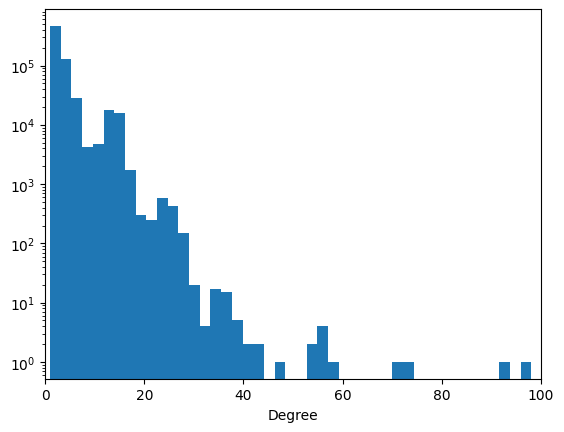

In [74]:
# histogram of degrees of nodes in G
degrees = torch.bincount(G.edge_index[0])
plt.hist(degrees.numpy(), bins=300)
plt.xlabel("Degree")
plt.yscale("log")
plt.xlim(0, 100)

In [70]:
high_degree_nodes = torch.where(degrees > 40)[0]
for n in high_degree_nodes:
    print(f"Node {n.item()} has degree {degrees[n].item()}")

Node 0 has degree 648
Node 1 has degree 638
Node 14252 has degree 56
Node 20234 has degree 41
Node 22403 has degree 57
Node 33332 has degree 42
Node 33333 has degree 53
Node 37392 has degree 43
Node 39651 has degree 55
Node 39652 has degree 54
Node 39957 has degree 47
Node 53393 has degree 55
Node 54605 has degree 107
Node 56063 has degree 121
Node 56065 has degree 115
Node 82749 has degree 92
Node 83610 has degree 59
Node 85349 has degree 74
Node 111742 has degree 131
Node 111771 has degree 72
Node 127890 has degree 98


In [92]:
le.transform(G.edge_y[3])

ValueError: y should be a 1d array, got an array of shape () instead.

Selected attack edge: 3 -> 668155 (src degree: 1)


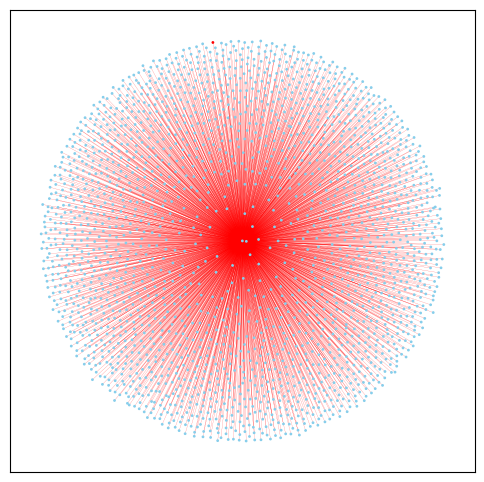

In [94]:
from torch_geometric.utils import to_undirected
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.utils import k_hop_subgraph, to_networkx
from torch_geometric.utils import to_undirected

edge_index_undirected = to_undirected(G.edge_index)

# select an attack edge
attacks = flows.Attack.unique()
attack_edges = np.where(G.edge_y != 2)[0]

# get src and dst of the attack edge
src, dst = G.edge_index[:, attack_edges[0]]

# get degree of src node
src_degree = (G.edge_index[0] == src).sum().item()
print(f"Selected attack edge: {src.item()} -> {dst.item()} (src degree: {src_degree})")

# Extract 2-hop subgraph
subset, edge_index, mapping, edge_mask = k_hop_subgraph(
    src.item(),
    2, 
    edge_index_undirected,
    relabel_nodes=True
)

from torch_geometric.data import Data
sub_data = Data(edge_index=edge_index, num_nodes=subset.size(0))
G_nx = to_networkx(sub_data, to_undirected=True)

# Highlight center node
node_colors = ["red" if i == mapping.item() else "skyblue" for i in G_nx.nodes()]

# --- Identify attack edges inside subgraph ---

# Original attack edge set (as tuples for fast lookup)
attack_edge_set = set(
    (int(G.edge_index[0, e]), int(G.edge_index[1, e]))
    for e in attack_edges
)

# Map subgraph edges back to original node indices
sub_edges_original = [
    (int(subset[u]), int(subset[v]))
    for u, v in edge_index.t().tolist()
]

# Determine edge colors + alpha
edge_colors = []
edge_alphas = []

for u, v in sub_edges_original:
    if (u, v) in attack_edge_set or (v, u) in attack_edge_set:
        edge_colors.append("red")
        edge_alphas.append(1.0)      # opaque
    else:
        edge_colors.append("gray")
        edge_alphas.append(0.05)     # very transparent


# --- Draw ---

plt.figure(figsize=(6,6))
pos = nx.spring_layout(G_nx, seed=42)

# Draw nodes
nx.draw_networkx_nodes(
    G_nx, pos,
    node_color=node_colors,
    node_size=1
)

# Draw edges individually to control alpha
for (u, v), color, alpha in zip(G_nx.edges(), edge_colors, edge_alphas):
    nx.draw_networkx_edges(
        G_nx, pos,
        edgelist=[(u, v)],
        edge_color=color,
        alpha=alpha,
        width=0.1 if color == "red" else 0.05
    )

plt.show()


In [116]:
le.inverse_transform([5])

array(['Fuzzers'], dtype=object)

(6000.0, 9000.0)

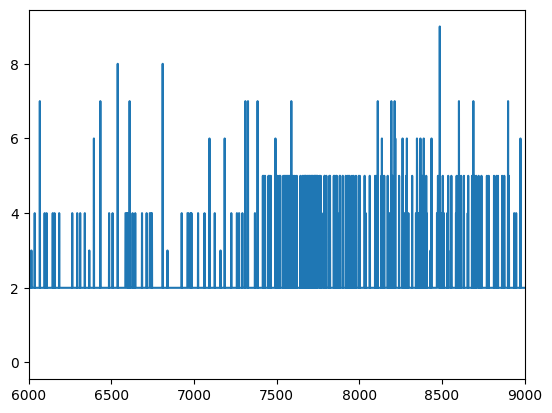

In [ ]:
plt.plot(flows.Attack)
plt.xlim(0.006e6, 0.009e6)

# observe Fuzzers attack between them

In [124]:
fuzzers_attack_df = flows.iloc[int(0.006e6):int(0.009e6)]
len(fuzzers_attack_df)

# only take benign edges that are adjacent to a fuzzer edge
fuzzer_nodes = set(fuzzers_attack_df['src'].unique()) | set(fuzzers_attack_df['dst'].unique())
fuzzers_attack_df = fuzzers_attack_df[
    (fuzzers_attack_df['src'].isin(fuzzer_nodes)) | 
    (fuzzers_attack_df['dst'].isin(fuzzer_nodes))
]

len(fuzzers_attack_df)

3000

In [125]:
# only take edges that are fuzzers
fuzzers_attack_df = fuzzers_attack_df[fuzzers_attack_df['Attack'] == le.transform(['Fuzzers'])[0]]
len(fuzzers_attack_df)

109

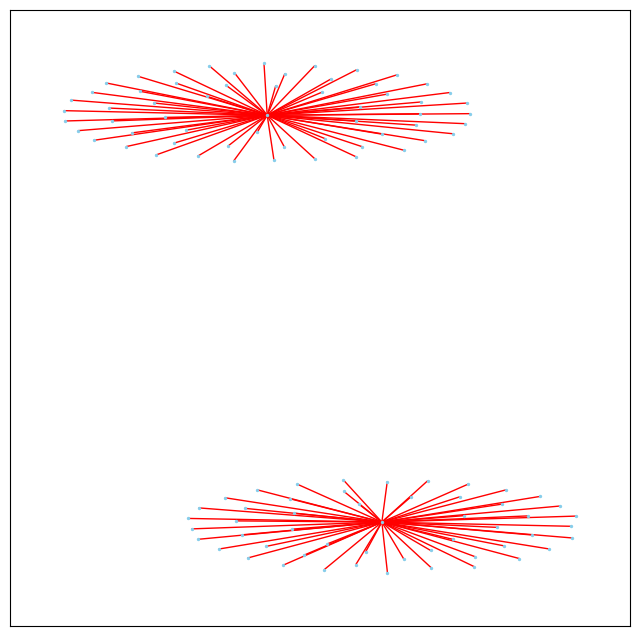

In [ ]:
# make graph of fuzzers attack dataframe, making fuzzer attack egdges red and rest gray, with red edges thicker and more opaque than gray edges

import matplotlib.pyplot as plt

# Create a NetworkX graph from the fuzzers_attack_df
G_attack = nx.from_pandas_edgelist(fuzzers_attack_df, source='src', target='dst', edge_attr='Attack')


attack_widths = {}
for i in range(0, 10):
    attack_widths[i] = 0.05  
attack_widths[le.transform(['Fuzzers'])[0]] = 1

attack_colors = {}
for i in range(0, 10):
    attack_colors[i] = 'gray'  
attack_colors[le.transform(['Fuzzers'])[0]] = 'red'


# Assign colors and widths to edges in the graph
edge_colors = [attack_colors[G_attack[u][v]['Attack']] for u, v in G_attack.edges()]
edge_widths = [attack_widths[G_attack[u][v]['Attack']] for u, v in G_attack.edges()]

# Draw the graph with custom edge colors and widths
plt.figure(figsize=(8,8))
pos = nx.spring_layout(G_attack, seed=42)
nx.draw_networkx_nodes(G_attack, pos, node_color='skyblue', node_size=2)
nx.draw_networkx_edges(G_attack, pos, edge_color=edge_colors, width=edge_widths)
plt.show()

Benign


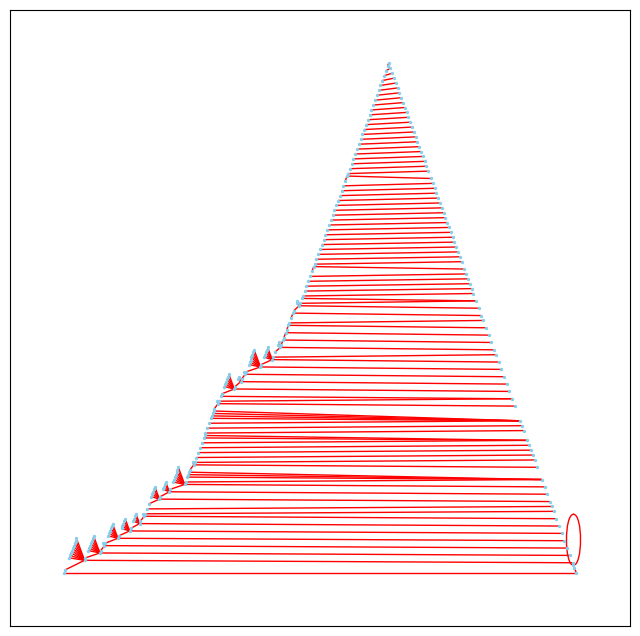

Reconnaissance


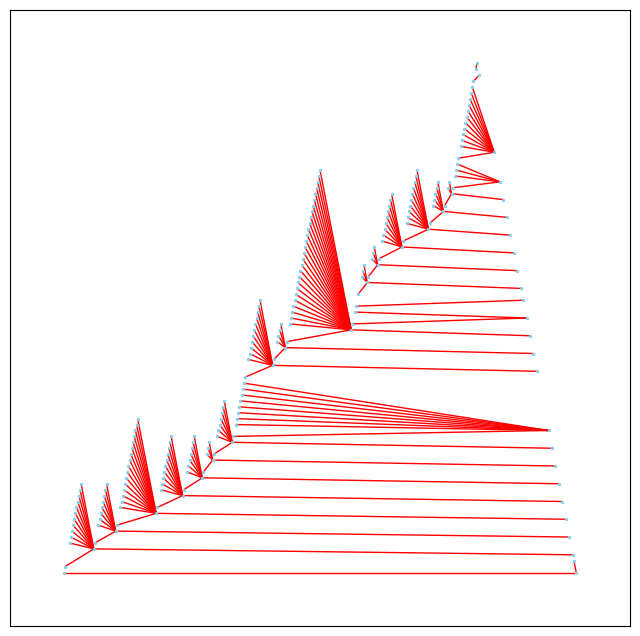

Exploits


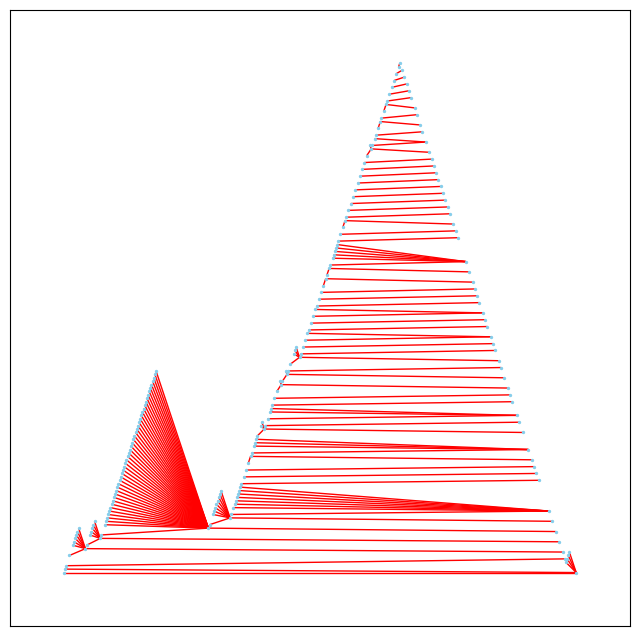

DoS


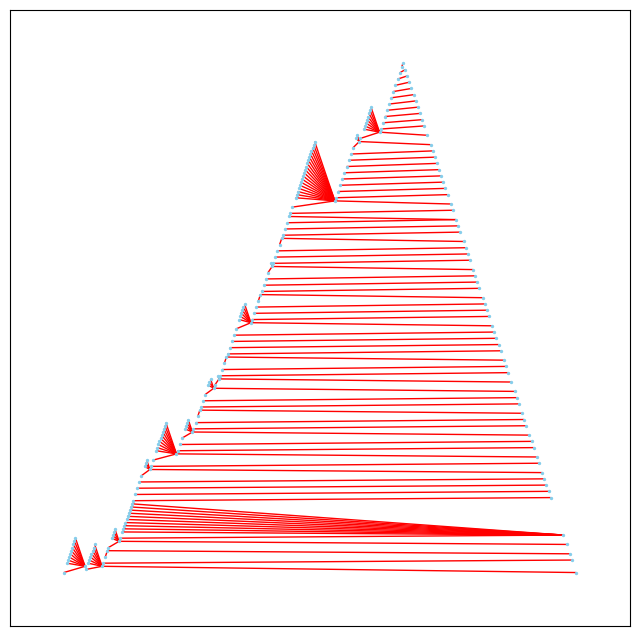

Generic


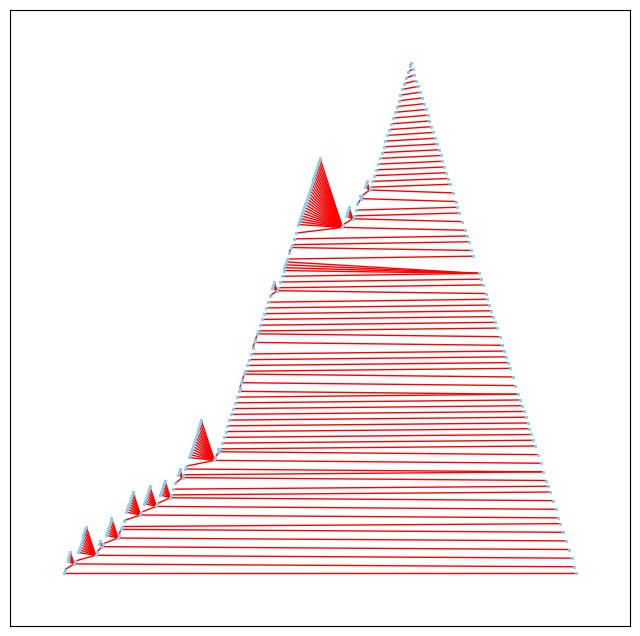

Shellcode


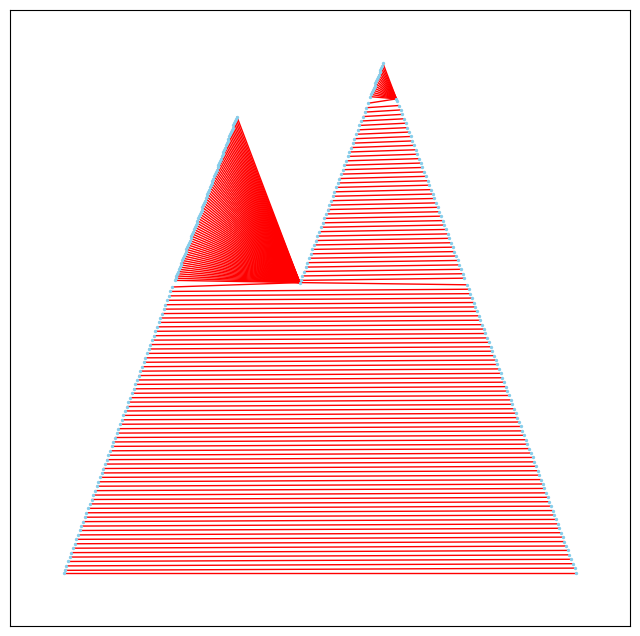

Fuzzers


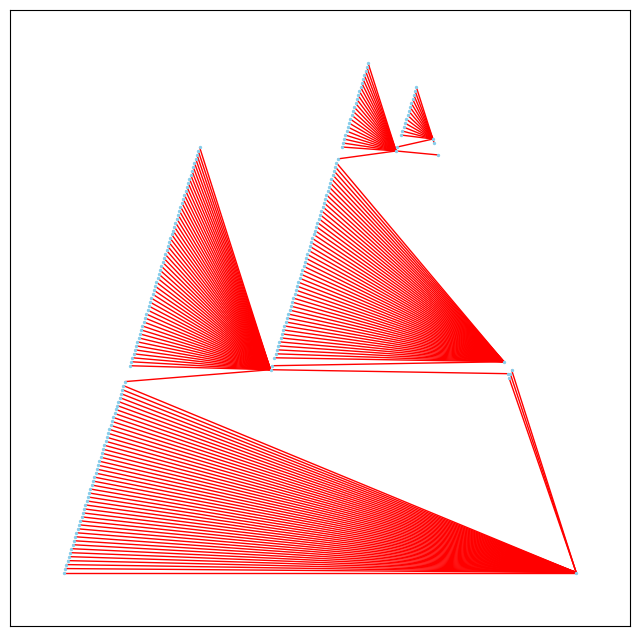

Worms


In [ ]:
# get a dataframe for each attack variety of 200 flows that are temporally close.

attack_varieties = flows['Attack'].unique()
attack_dfs = {}
for attack in attack_varieties:
    print(le.inverse_transform([attack])[0])

    attack_df = flows[flows['Attack'] == attack]

    edge_idxs = []
    sampled_flows = 0
    for i, flow in flows.iterrows():
        if flow.Attack == attack:
            edge_idxs.append(i)
            sampled_flows += 1
            if sampled_flows >= 200:
                break

    attack_dfs[attack] = flows.iloc[edge_idxs]

    G_attack = nx.from_pandas_edgelist(attack_dfs[attack], source='src', target='dst', edge_attr='Attack')

    # Draw the graph with custom edge colors and widths
    plt.figure(figsize=(8,8))
    pos = nx.planar_layout(G_attack)
    nx.draw_networkx_nodes(G_attack, pos, node_color='skyblue', node_size=2)
    nx.draw_networkx_edges(G_attack, pos, edge_color='red', width=1)
    plt.show()

Selected attack edge: 3 -> 668155 (src degree: 1)


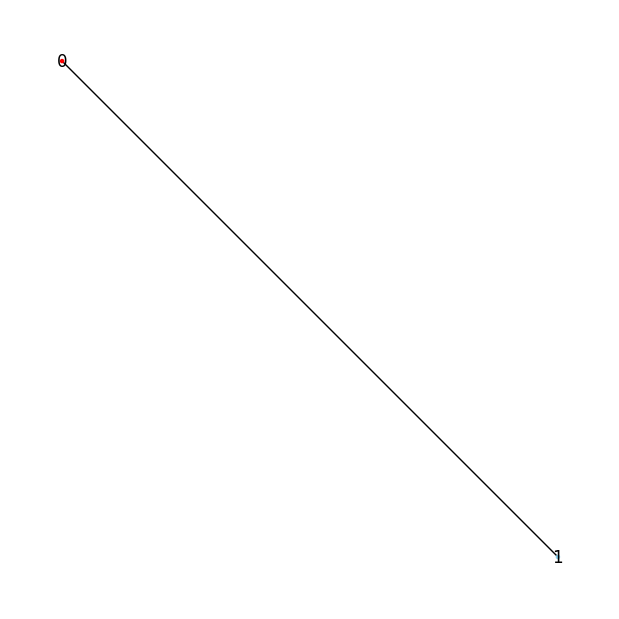

Selected attack edge: 44 -> 668155 (src degree: 1)


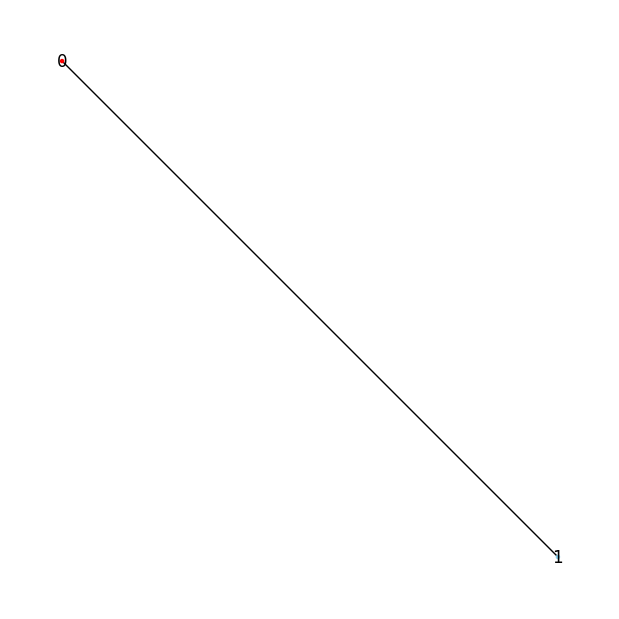

In [89]:
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.utils import k_hop_subgraph, to_networkx
from torch_geometric.utils import to_undirected

from torch_geometric.utils import to_undirected
edge_index_undirected = to_undirected(G.edge_index)


for i in range(2):

    # select an attack edge
    attacks = flows.Attack.unique()
    attack_edges = np.where(G.edge_y != 2)[0]

    # get src and dst of the attack edge
    src, dst = G.edge_index[:, attack_edges[i]]

    # get degree of src node
    src_degree = (G.edge_index[0] == src).sum().item()
    print(f"Selected attack edge: {src.item()} -> {dst.item()} (src degree: {src_degree})")

    # Extract 2-hop subgraph
    subset, edge_index, mapping, edge_mask = k_hop_subgraph(
        src.item(),
        1, 
        edge_index_undirected,
        relabel_nodes=True
    )

    # Create new PyG data object for subgraph
    from torch_geometric.data import Data
    sub_data = Data(edge_index=edge_index, num_nodes=subset.size(0))

    # Convert only the subgraph to NetworkX
    G_nx = to_networkx(sub_data, to_undirected=True)

    # Draw
    plt.figure(figsize=(6,6))
    pos = nx.random_layout(G_nx, seed=42)

    # Highlight center node
    node_colors = ["red" if i == mapping.item() else "skyblue" for i in G_nx.nodes()]

    nx.draw(G_nx, pos,
            node_color=node_colors,
            with_labels=True,
            node_size=5)

    plt.show()